# Attention mechanism

이 장에서는 먼저 NumPy 예제로 Attention의 계산 원리를 살펴본다. 이후 Encoder-Decoder에 Attention을 적용하고, 마지막으로 Transformer에서 사용하는 Query, Key, Value 표현으로 확장한다. 추가 예제와 단계별 추론 코드는 처음 읽을 때 건너뛰어도 된다.

어텐션 메커니즘은 시퀀스-투-시퀀스(seq2seq) 모델에서 입력 시퀀스의 중요한 부분에 집중할 수 있도록 돕는 기술이다. 

앞에서 살펴본 encoder-decoder 모형에 어텐션 메커니즘을 추가해 보자.

여기서는 가장 간단한 dot-product attention을 이용하여 Attention의 원리를 살펴본다.

먼저 numpy array로 어텐션 과정을 훑어보자.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2) 

# 길이 6의 인코더 출력 및 디코더 출력 생성
encoder_timesteps = 6
decoder_timesteps = 6

가상의 인코더 출력과 디코더 출력 시퀀스를 생각해 보자.

- 인코더 출력은 랜덤하게 구성되어 있다.

- 디코더 출력은 인코딩 출력을 한 타임스텝만큼 뒤로 이동시킨 후 약간의 노이즈를 추가하였다.

- 디코더 출력의 첫 번째 값은 다시 랜덤하게 설정.

In [2]:
latent_dim = 4

# 인코더 출력 (임의의 값)
encoder_outputs = np.random.normal(0, 1, size=(encoder_timesteps, latent_dim))  # shape : (encoder_timesteps, latent_dim)
# 디코더 출력 
decoder_outputs = np.roll(encoder_outputs, shift=1, axis=0)
decoder_outputs[0] = np.random.normal(0, 0.1, latent_dim)
decoder_outputs = decoder_outputs + np.random.normal(0, 0.01, decoder_outputs.shape)  # shape : (decoder_timesteps, latent_dim)

print(encoder_outputs[:, 0])
print(decoder_outputs[:, 0])

[-0.41675785 -1.79343559 -1.05795222  0.04153939 -0.0191305  -0.87810789]
[-0.04809437 -0.44110552 -1.78841701 -1.0610873   0.05621617 -0.02742185]


### Attention Weights

`encoder_outputs`과 `decoder_outputs` 간의 Dot product 결과를 이용하여 유사도를 측정하고, 이를 통해 디코더가 인코더의 어느 시점에 집중할지를 결정한다.

- 여기서 `encoder_outputs`는 키(key) 및 값(value), `decoder_outputs`는 쿼리(query)이 역할을 한다.

이 후, dot product로 계산된 유사성을 각 행별로 적용된 소프트맥스를 통해 각 타임스텝에 대한 확률 분포를 얻는다. 

이 확률 분포는 각 인코더 출력이 현재 디코더 상태에 얼마나 중요한지를 나타낸다.

수식으로 나타내면 다음과 같다.

$$
\text{Attention Scores} = \mathrm{Q} \, \mathrm{K}^{\top}, \quad \text{Attention Weights} = \text{softmax}(\text{Attention Scores}) = \frac{\exp(\text{Attention Scores})}{\sum \exp(\text{Attention Scores})}
$$

- $\mathrm{Q}$는 쿼리 즉, 이 예제에서는 `decoder_outputs`으로 이루어진 행렬.
- $\mathrm{K}$는 키 즉, 이 예제에서는 `encoder_outputs`으로 이루어진 행렬.

마지막으로, 이 확률 분포를 Value에 곱해 context vector를 생성한다:

$$
\text{Context Vector} = \text{Attention Weights} \cdot \mathrm{V}
$$

이 context vector는 디코더가 출력을 생성하는 데 참조하는 **요약된 인코더 정보**이다.

즉, 전체 attention 과정은 다음으로 요약된다.

$$
\text{Attention}(\mathrm{Q}, \mathrm{K}, \mathrm{V}) = \mathrm{softmax}(\mathrm{Q}\mathrm{K}^\top) \mathrm{V}
$$

In [3]:
# Attention 가중치 계산 (여기서는 단순한 내적)
attention_scores = decoder_outputs @ encoder_outputs.T
# Softmax 적용하여 가중치 정규화
attention_weights = np.exp(attention_scores) / np.sum(np.exp(attention_scores), axis=1, keepdims=True)
# 소수점 둘째 자리까지 출력
print("Attention Weight : ")
print("\n".join([", ".join([f"{item:.2f}" for item in row]) for row in attention_weights]))

Attention Weight : 
0.16, 0.19, 0.13, 0.17, 0.16, 0.18
0.98, 0.00, 0.01, 0.00, 0.00, 0.00
0.00, 0.91, 0.00, 0.02, 0.00, 0.06
0.01, 0.00, 0.99, 0.00, 0.00, 0.00
0.01, 0.38, 0.05, 0.40, 0.01, 0.14
0.36, 0.02, 0.02, 0.01, 0.54, 0.05


### Context Vector

Context vector는 입력 시퀀스에서 추출한 의미 정보를 압축한 벡터로, 디코더가 출력 시퀀스를 생성하는 데 사용하는 핵심 정보.

`attention_weights`과  `encoder_outputs`과의 행렬 곱을 이용하여 생성되는 벡터이다. 

$$
\text{Context Vector} = \text{Attention Weights} \cdot \mathrm{V}
$$

- 이 예제에서는 `encoder_outputs`는 키 뿐만 아니라 값(value)의 역할 또한 담당한다고 이야기할 수 있다.
- 이 예제에서는 key와 value가 같지만, 실제 모델에서는 key와 value는 다르게 구현될 수 있다.

이 컨텍스트 벡터는 디코더가 출력 시퀀스를 생성하는 데 필요한 입력으로 사용된다.

In [4]:
# Context 벡터 계산
context_vectors = attention_weights @ encoder_outputs
print(context_vectors)

[[-0.7111741  -0.31754961 -0.15752842  0.04922324]
 [-0.42414254 -0.06420603 -2.09683405  1.64381166]
 [-1.6946996  -0.80196681  0.48631592 -1.20261437]
 [-1.04981333 -0.89819643  0.51821052  2.27999331]
 [-0.85705629 -0.83286569  0.45276622 -0.72247738]
 [-0.2629155   0.5506332  -1.12175053  0.54550675]]


시각화를 이용하여 살펴보자.

In [5]:
def plot_matrix(ax, matrix, title, x_label, y_label):
    cax = ax.matshow(matrix, cmap='coolwarm')
    ax.set_title(title, pad=20)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.xaxis.set_ticks_position('bottom')
    for (i, j), val in np.ndenumerate(matrix):
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')

아래 시각화 결과를 보면 `encoder_outputs`과 `decoder_outputs` 간의 매트릭스 곱을 통하여 (softmax를 취한 후) `attention_weights`가 생성되는 과정을 볼 수 있다.

$$\text{Attention Scores} = \mathrm{Q} \, \mathrm{K}^{\top}, \quad \text{Attention Weights} = \text{softmax}(\text{Attention Scores})$$

`attention_weights`는 디코더의 각 타임스텝에서 인코더 출력의 어느 타임스텝에 집중해야 하는지 보여준다. Attention matrix의 각 행은 하나의 Query(디코더) 시점을, 각 열은 하나의 Key(인코더) 시점을 나타낸다.

예를 들어, 

- 디코더의 타임스텝 1에서는 인코더의 타임스템 0와의 `attention_weights`값이 가장 크므로, 인코더의 타임스템 0에 집중해야 한다.
- 마찬가지로, 디코더의 타임스텝 2에서는 인코더의 타임스템 1에 집중해야 한다.
- 마찬가지로, 디코더의 타임스텝 3에서는 인코더의 타임스템 2에 집중해야 한다.

이것은 디코더 출력이 인코더 출력을 한 칸씩 뒤로 밀어 생성한 것이기 때문이다.

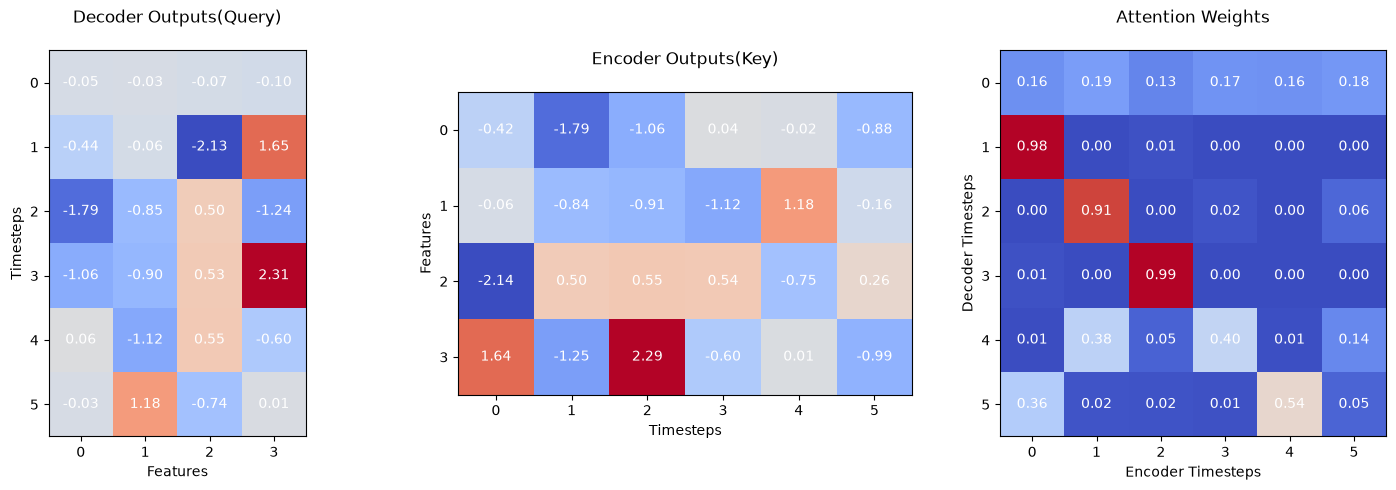

In [6]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_matrix(axes[0], decoder_outputs, 'Decoder Outputs(Query)',  'Features', 'Timesteps')
plot_matrix(axes[1], encoder_outputs.T, 'Encoder Outputs(Key)', 'Timesteps', 'Features')

plot_matrix(axes[2], attention_weights, 'Attention Weights', 'Encoder Timesteps', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

`attention_weights`와 `encoder_outputs` 간의 매트릭스 곱을 통하여 context vector가 만들어진다.

Attention은 모든 Value를 사용하되, 현재 Query와 관련성이 높은 Value에는 큰 가중치를 부여한다. Context vector는 이러한 Value들의 가중합이다.

입력 시퀀스의 모든 정보를 디코더에 직접 전달하는 대신, 가중합을 통해 정보를 집약하여 긴 시퀀스에서도 디코더가 필요한 정보에 쉽게 접근할 수 있게 한다.

아래 예제에서는 Enconder outputs(value)의 값이 context vectors에서 1 timestep 씩 뒤로 밀린 형태와 흡사함을 주목하라. 

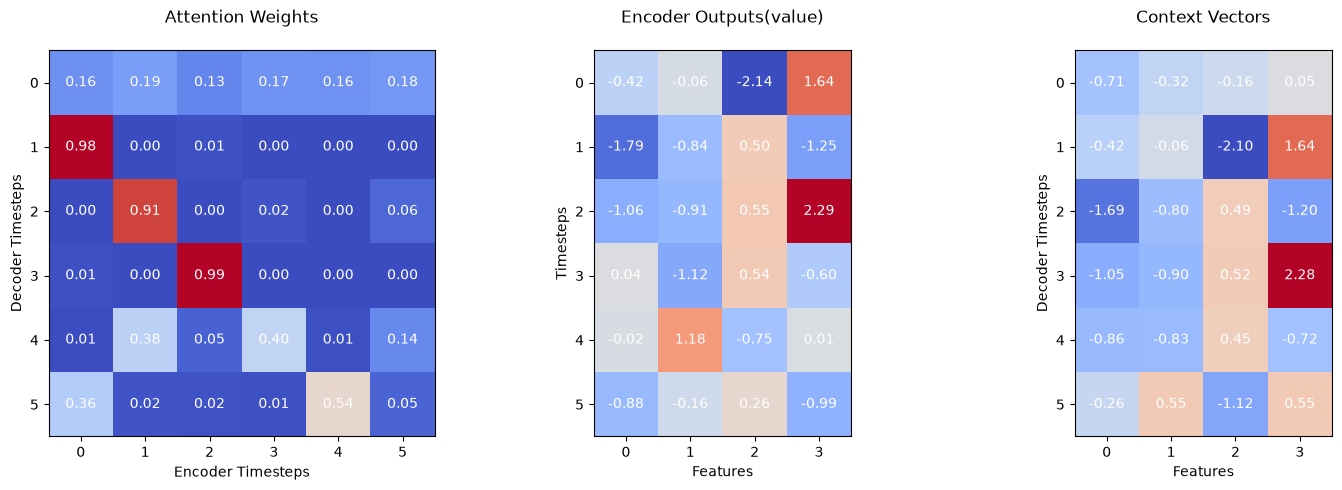

In [7]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_matrix(axes[0], attention_weights, 'Attention Weights', 'Encoder Timesteps', 'Decoder Timesteps')

plot_matrix(axes[1], encoder_outputs, 'Encoder Outputs(value)', 'Features', 'Timesteps')

plot_matrix(axes[2], context_vectors, 'Context Vectors', 'Features', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

최종적으로 `context_vectors`와 `decoder_outputs`을 concatenate하여 살펴보자.

이렇게 concatenate 된 데이터가 마지막 dense layer로 전달되어 time step별로 처리된다고 생각하면 된다.

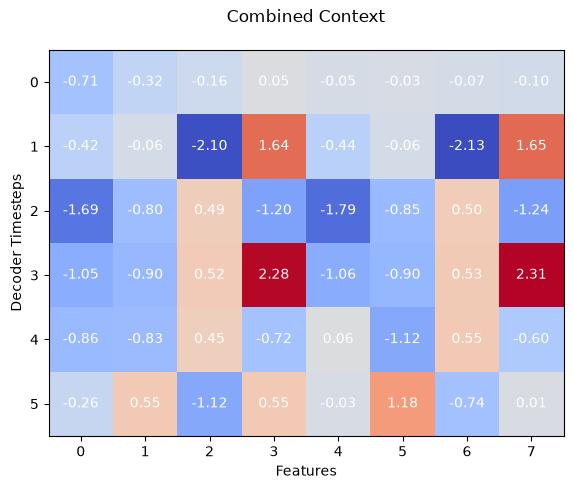

In [8]:
decoder_combined_context = np.concatenate([context_vectors, decoder_outputs], axis=-1)

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# combined context: (batch, decoder_timesteps, 2 * latent_dim)
plot_matrix(axes, decoder_combined_context, 'Combined Context', 'Features', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

**추가 예제: 뒤집힌 시퀀스의 Attention** — 앞의 계산과 동일한 원리를 다른 형태의 시퀀스에 적용해 본다. 첫 번째 예제를 이해했다면 이 절은 빠르게 확인해도 된다.

In [9]:
# 인코더 출력 (임의의 값)
encoder_outputs = np.random.normal(0, 1, size=(encoder_timesteps, latent_dim))
# 디코더 출력 
decoder_outputs = np.flip(encoder_outputs, axis=0) + 1 

# Attention 가중치 계산 (여기서는 단순한 내적)
attention_scores = np.dot(decoder_outputs, encoder_outputs.T)

# Softmax 적용하여 가중치 정규화
attention_weights = np.exp(attention_scores) / np.sum(np.exp(attention_scores), axis=1, keepdims=True)

# Context 벡터 계산
context_vectors = np.dot(attention_weights, encoder_outputs)

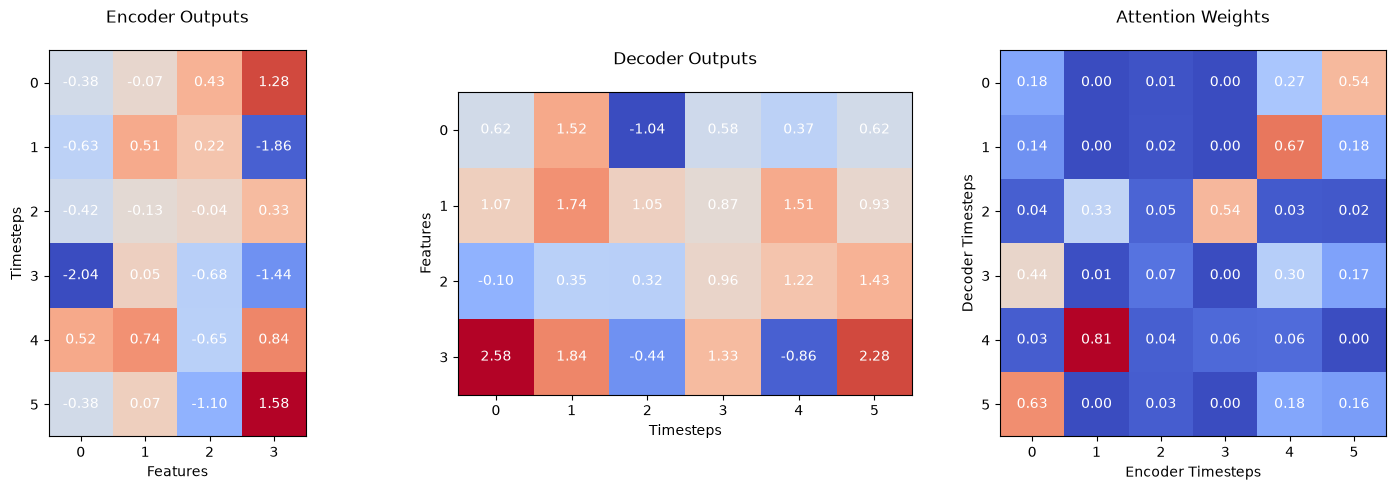

In [10]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_matrix(axes[0], encoder_outputs, 'Encoder Outputs', 'Features', 'Timesteps')
plot_matrix(axes[1], decoder_outputs.T, 'Decoder Outputs', 'Timesteps', 'Features')

plot_matrix(axes[2], attention_weights, 'Attention Weights', 'Encoder Timesteps', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

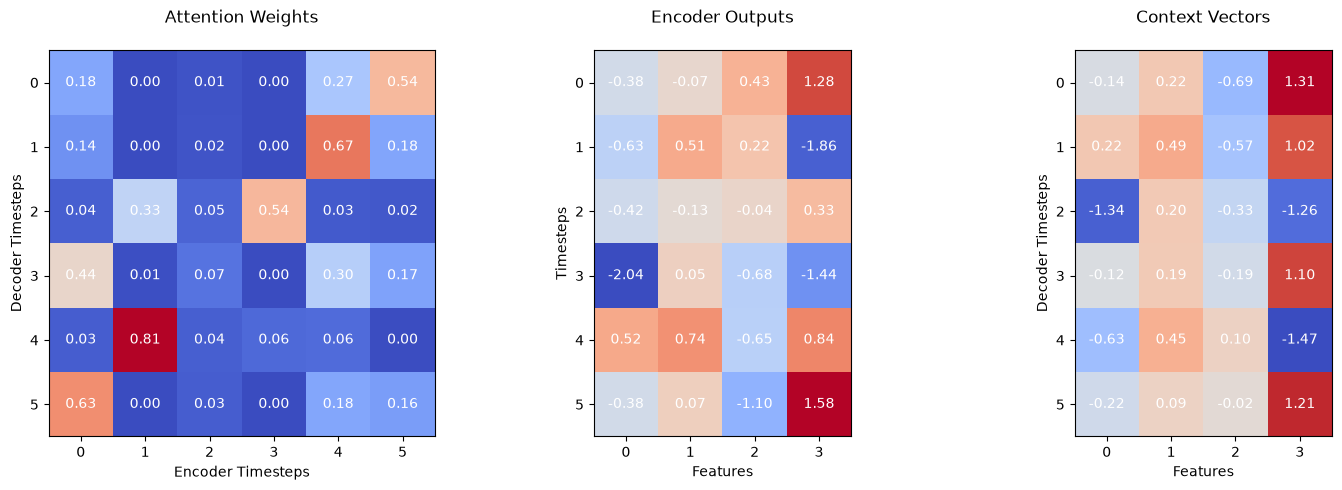

In [11]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_matrix(axes[0], attention_weights, 'Attention Weights', 'Encoder Timesteps', 'Decoder Timesteps')

plot_matrix(axes[1], encoder_outputs, 'Encoder Outputs', 'Features', 'Timesteps')

plot_matrix(axes[2], context_vectors, 'Context Vectors', 'Features', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

최종적으로 `context_vectors`와 `decoder_outputs`을 concatenate하여 살펴보자.

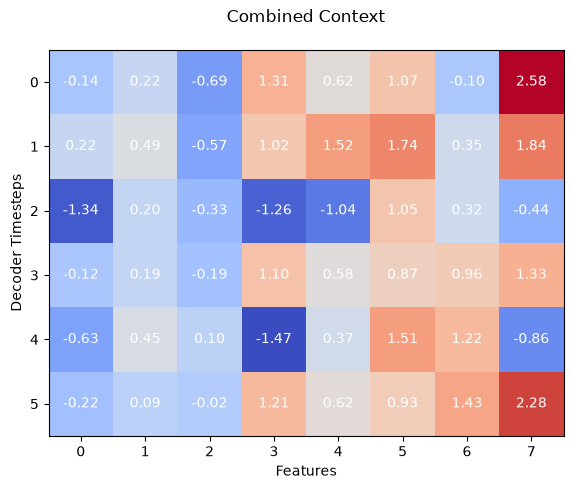

In [12]:
decoder_combined_context = np.concatenate([context_vectors, decoder_outputs], axis=-1)

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# combined context: (batch, decoder_timesteps, 2 * latent_dim)
plot_matrix(axes, decoder_combined_context, 'Combined Context', 'Features', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

## Attention이 추가된 encoder-decoder 모형

이제 어텐션 메카니즘이 추가된 인코더-디코더 모형을 살펴보자.

먼저, enconder-decoder 모형은 이전 단원에서 했던 것과 비슷하게 구성하였다.

아래, 인코더의 출력 `encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)`을 보자.

여기서 `encoder_outputs`은  각 시점의 은닉 상태 벡터이다.

LSTM은 시퀀스를 한 시점씩 처리하며,

x₁ ─────▶ h₁, c₁  
x₂ ─────▶ h₂, c₂  
x₃ ─────▶ h₃, c₃  
x₄ ─────▶ h₄, c₄  
x₅ ─────▶ h₅, c₅  
x₆ ─────▶ h₆, c₆ 

와 같이 표현할 수 있고, 다음과 같다.

- `encoder_outputs = [h₁, h₂, h₃, h₄, h₅, h₆]`

- `state_h = h₆` (가장 마지막 은닉 상태)

- `state_c = c₆` (가장 마지막 셀 상태)

In [13]:
from keras.layers import Input, LSTM, Dense, Concatenate, Dot, Activation
from keras.models import Model
import numpy as np

# 입력 데이터 및 모델 파라미터 설정
timesteps = 6
input_dim = 3      # 3차원 입력, 출력 시퀀스
latent_dim = 50    # LSTM 유닛 수

# 인코더 정의
encoder_inputs = Input(shape=(timesteps, input_dim), name='encoder_input')
encoder_lstm = LSTM(latent_dim, return_state=True, return_sequences=True, name='encoder_lstm')
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# 디코더 정의 (훈련용)
decoder_inputs = Input(shape=(timesteps, input_dim), name='decoder_input')
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

decoder_outputs, encoder_outputs

(<KerasTensor shape=(None, 6, 50), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>,
 <KerasTensor shape=(None, 6, 50), dtype=float32, sparse=False, ragged=False, name=keras_tensor>)

#### Attention 구현

아래에서 [`Dot`](https://keras.io/api/layers/merging_layers/dot/)은 디코더 출력(decoder_outputs)과 인코더 출력(encoder_outputs) 간의 dot product를 계산한다.

- 위의 예제에서처럼 디코더 출력(decoder_outputs)은 query, 인코더 출력(encoder_outputs)은 key라고 표현한다.

- `Axes=[2, 2]` 여기서 두 텐서의 마지막 차원(axis 2)을 기준으로 dot product를 수행한다.

  - `latent_dim = 50` 길이의 두 벡터들 간의 dot product가 수행됨 <br><br>

- 이는 디코더의 각 타임스텝 출력과 인코더의 각 타임스텝 출력 간의 유사도를 계산하는 과정이다.

- 모든 디코더 시점(6개) × 모든 인코더 시점(6개) 조합으로 dot product을 진행하므로 `shape=(None, 6, 6)`이다.

   - `(batch_size, decoder_timesteps, encoder_timesteps)`

   - 각 배치 내에서 디코더의 각 타임스텝에 대해 인코더의 각 타임스텝과의 유사도 점수

In [14]:
attention_scores = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])
attention_scores

<KerasTensor shape=(None, 6, 6), dtype=float32, sparse=False, ragged=False, name=keras_tensor_6>

Softmax Activation: dot product를 통해 얻은 유사도 점수는 softmax 활성화 함수를 통해 정규화 된다.

- 이 과정은 각 디코더 타임스텝에 대해 인코더 타임스텝의 중요도를 0과 1사이의 확률로 변환한다.

- 결과: 각 디코더 타임스텝에서 인코더 타임스텝 중 어디에 집중해야 하는지를 알려주는 가중치(Attention Weights)를 얻게 된다.

- 이 예제에서는 $7\times 6$ 크기의 행렬을 얻게 된다.

In [15]:
attention_weights = Activation('softmax', name='attention')(attention_scores)
attention_weights

<KerasTensor shape=(None, 6, 6), dtype=float32, sparse=False, ragged=False, name=keras_tensor_7>

가중치 행렬 `attention_weights`와 `encoder_outputs`의 곱을 취하여 context 벡터로 이루어진 행렬을 생성한다.

- $7\times 6$ 행렬과 $6 \times 50$ 행렬의 곱이므로 $7 \times 50$ 행렬을 얻는다.

- `attention` 행렬에 `encoder_outputs`을 value로 취하여 곱을 취하는 과정.

- 이를 `Dot`을 이용하여 표현하면 아래 코드와 같다.  
  - 원래의 encoder output에 시퀀스의 어디가 중요한지가 반영된 버전이라 하겠다. <br><br>
 
- `context`의 shape의 timestep은 `decoder_outputs`의 timestep과 동일한 7임을 주목하라.

In [16]:
context = Dot(axes=[2, 1])([attention_weights, encoder_outputs])
context

<KerasTensor shape=(None, 6, 50), dtype=float32, sparse=False, ragged=False, name=keras_tensor_8>

`context`와 `decoder_outputs`를 연결하여 다음 레이어로 전달할 것이다.

- `Concatenate(axis=-1, name='decoder_combined_context')([context, decoder_outputs])`

`context`에는 `decoder_outputs`를 최종 예측값으로 변환하는데 도움이 되는 요소가 담겨 있음.

`decoder_outputs`: 현재 시점의 디코더 LSTM 출력으로, 이전 상태와 현재 입력을 반영한 예측 계산을 위한 중간 과정 값 

- `decoder_output[0, 0, :]`를 이용하여 최종 결과를 계산할 때 도움이 되는 요소는 `context[0, 0, :]`에 요약되어 있다.
- `decoder_output[0, t, :]`를 이용하여 최종 결과를 계산할 때 도움이 되는 요소는 `context[0, t, :]`에 요약되어 있다.

In [17]:
decoder_combined_context = Concatenate(axis=-1, name='decoder_combined_context')([context, decoder_outputs])
decoder_combined_context

<KerasTensor shape=(None, 6, 100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>

In [18]:
decoder_dense = Dense(input_dim, activation='linear', name='decoder_output')
decoder_outputs = decoder_dense(decoder_combined_context)

# 모델 구성
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)


이 모델을 간단히 표현하면 다음과 같다.

```
encoder_input → [Encoder LSTM] → encoder_outputs →  [Attention] →  context 
                      ↓                                 ↑             ↓
                      ↓ h, c                            ↑             ↓
                      ↓                                 ↑             ↓
decoder_input → [Decoder LSTM] → decoder_outputs →      →       → [Concatenate] → [Dense] → final_output
```

더 자세히 표현하면 
```
encoder_input → [Encoder LSTM] → h, c, encoder_outputs 
                                   ↓           ↓
                                   ↓           ↓
decoder_input → [Decoder LSTM] (uses h, c)     ↓
                    ↓                          ↓
              decoder_outputs                  ↓
                    ↓                          ↓
                    ↓                          ↓
    [Dot Product] (decoder_outputs, encoder_ouputs) → attention scores
                                     
                    → [Softmax] → attention weights
                                     ↓
                                     ↓
    [Dot Product (Attention)] (attention_weights, encoder_outputs) → context
                                     ↓  
    [Concatenate] ([context, decoder_outputs]) → [Dense] → final_output
```

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 6, 50),   │     10,800 │ encoder_input[0]… │
│                     │ (None, 50),       │            │                   │
│                     │ (None, 50)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 6, 50),   │     10,800 │ decoder_input[0]… │
│                     │ (None, 50),       │            │ encoder_lstm[0][… │
│                     │ (None, 50)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 6, 6)      │          0 │ decoder_lstm[0][… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 6, 6)      │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 6, 50)     │          0 │ attention[0][0],  │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_combined_c… │ (None, 6, 100)    │          0 │ dot_1[0][0],      │
│ (Concatenate)       │                   │            │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 6, 3)      │        303 │ decoder_combined… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,903 (85.56 KB)

 Trainable params: 21,903 (85.56 KB)

 Non-trainable params: 0 (0.00 B)

위의 모델 요약에서 볼 수 있듯이, 여기서 구현한 `Dot → Softmax → Dot` 형태의 Attention 계산 자체에는 별도의 학습 가능한 parameter가 없다. 

그러나 Attention이 적용된 Context 벡터는 LSTM이나 Dense 레이어 등과 함께 사용되므로, 전체 모델 학습 과정에서는 간접적으로 학습이 이루어진다.

- 즉, 모델은 최적의 Attention 가중치가 생성되도록 인코더와 디코더의 출력을 학습한다.

- 컨텍스트 벡터는 인코더 출력과 Attention 가중치의 가중합이므로, 좋은 Attention 분포를 얻기 위해 인코더의 출력 표현이 정교하게 학습된다.

### 훈련

이전에 했던 예제와 비슷하게 `target_sequences`는 `input_sequences`를 시간 축에 대해 뒤집은 후 1을 더해 생성하였다.

`input_sequences`의 shape은 다음과 같다.

- `(num_samples, timesteps = 6, input_dim = 3)`

In [20]:
num_samples = 10000
input_sequences = np.random.uniform(0, 100, size=(num_samples, timesteps, input_dim))

# 데이터 전처리
input_sequences = input_sequences.astype(np.float32)
target_sequences = np.flip(input_sequences, axis=1) + 1

print("input_sequences shape:", input_sequences.shape)
print("target_sequences shape:", target_sequences.shape)

input_sequences shape: (10000, 6, 3)
target_sequences shape: (10000, 6, 3)


`start_token`과 `end_token`을 설정하여 디코더에 활용한다.

여기서도 디코더가 이전 시점의 실제 정답을 입력으로 받는 방식인 Teacher forcing 방법을 훈련에 사용할 것이다. 이 예제는 출력 길이가 이미 정해져 있으므로 종료 토큰은 사용하지 않는다. 번역처럼 출력 길이를 미리 알 수 없는 문제에서는 시작 토큰과 종료 토큰을 함께 사용한다.

- `decoder_input_data_with_start_token` → 디코더 입력 ($Y_{t-1}$)

- `output_data_with_end_token` → 디코더 출력 목표 ($Y_t$)


In [21]:
start_token = np.zeros((target_sequences.shape[0], 1, input_dim), dtype=np.float32)
decoder_input_data = np.concatenate([start_token, target_sequences[:, :-1, :]], axis=1)
target_data = target_sequences

print("Encoder input data  : \n",  np.squeeze(input_sequences[0, :, :]))
print("Decoder input data  : \n", np.squeeze(decoder_input_data[0, :, :]))
print("Target data         : \n", np.squeeze(target_data[0, :, :]))

Encoder input data  : 
 [[49.70738  41.490585 35.08719 ]
 [55.09779  97.29107  11.277621]
 [31.325853  4.179771 73.83997 ]
 [65.751236 21.463575 41.675343]
 [64.38419  66.14813  17.047714]
 [88.16522  77.80082  13.395421]]
Decoder input data  : 
 [[ 0.        0.        0.      ]
 [89.16522  78.80082  14.395421]
 [65.38419  67.14813  18.047714]
 [66.751236 22.463575 42.675343]
 [32.32585   5.179771 74.83997 ]
 [56.09779  98.29107  12.277621]]
Target data         : 
 [[89.16522  78.80082  14.395421]
 [65.38419  67.14813  18.047714]
 [66.751236 22.463575 42.675343]
 [32.32585   5.179771 74.83997 ]
 [56.09779  98.29107  12.277621]
 [50.70738  42.490585 36.08719 ]]


In [22]:
model.compile(optimizer='adam', loss='mean_squared_error')

훈련에 사용되는 값 정리

- `input_sequences` : 인코더 input
- `decoder_input_data_with_start_token` : 디코더 input
- `output_data_with_end_token` : 디코더 output을 훈련하기 위한 타겟으로 정답 시퀀스

In [23]:
history = model.fit([input_sequences, decoder_input_data], target_data, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

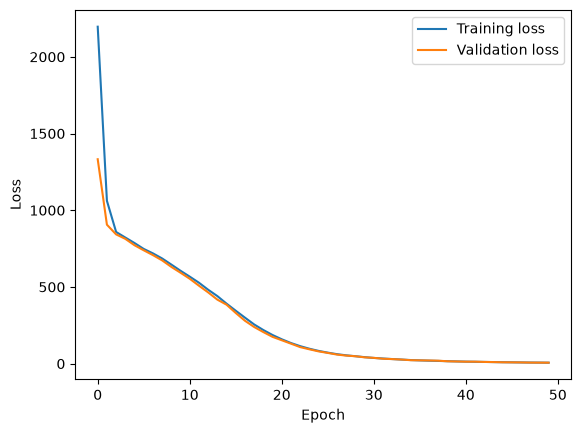

In [24]:
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 예측 (심화 구현)

Encoder-Decoder의 단계별 예측 과정은 앞 장(7장)과 같다. 차이점은 각 Decoder step에서 Encoder의 전체 출력과 attention weight를 이용하여 context vector를 계산한다는 것이다.

1. Encoder 출력과 초기 상태 계산
2. Decoder의 한 스텝 출력 계산
3. Encoder 출력과 attention 계산
4. Context vector를 이용하여 다음 값 예측
5. 예측값과 상태를 갱신하고 반복

- 예측 단계에서는 `decoder_outputs.shape = (batch_size, 1, latent_dim)`
- 훈련 단계에서는 `decoder_outputs.shape = (batch, timesteps, latent_dim)`

In [25]:
# 예측을 위한 모델 설정
# 인코더는 기존의 모델 그대로 이용
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])

# 디코더의 입력이 한 번에 하나의 값을 받음
decoder_single_input = Input(shape=(1, input_dim), name="previous_prediction")
decoder_state_input_h = Input(shape=(latent_dim,), name="hidden_status")
decoder_state_input_c = Input(shape=(latent_dim,), name="cell_status")
encoder_output_input = Input(shape=(timesteps, latent_dim), name="encoder_output")

# 훈련된 decoder_lstm을 이용
decoder_outputs, state_h, state_c = decoder_lstm(decoder_single_input, initial_state=[decoder_state_input_h, decoder_state_input_c])

attention_scores = Dot(axes=[2, 2], name="attention_scores")([decoder_outputs, encoder_output_input])
attention_weights = Activation('softmax', name="attention_weights")(attention_scores)
context = Dot(axes=[2, 1], name="context_vector")([attention_weights, encoder_output_input])
decoder_combined_context = Concatenate(axis=-1)([context, decoder_outputs])

# 훈련된 decoder_dense를 이용
decoder_outputs = decoder_dense(decoder_combined_context)

decoder_states = [state_h, state_c]

decoder_model = Model(
    inputs=[decoder_single_input, encoder_output_input, decoder_state_input_h, decoder_state_input_c],
    outputs=[decoder_outputs] + decoder_states)

decoder_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ previous_prediction │ (None, 1, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_status       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cell_status         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 50),   │     10,800 │ previous_predict… │
│                     │ (None, 50),       │            │ hidden_status[0]… │
│                     │ (None, 50)]       │            │ cell_status[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_output      │ (None, 6, 50)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_scores    │ (None, 1, 6)      │          0 │ decoder_lstm[1][… │
│ (Dot)               │                   │            │ encoder_output[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 1, 6)      │          0 │ attention_scores… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector      │ (None, 1, 50)     │          0 │ attention_weight… │
│ (Dot)               │                   │            │ encoder_output[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1, 100)    │          0 │ context_vector[0… │
│ (Concatenate)       │                   │            │ decoder_lstm[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 1, 3)      │        303 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,103 (43.37 KB)

 Trainable params: 11,103 (43.37 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
new_input_sequence = np.array([[[11., 21., 93.],
                                [19., 22., 34.],
                                [13., 33., 25.],
                                [32., 14., 26.],
                                [56., 75., 47.],
                                [26., 76., 58.]]])

encoder_output, h, c = encoder_model.predict(new_input_sequence, verbose=0)

# 디코더의 초기 입력 (시작 토큰)
target_seq = np.zeros((1, 1, input_dim))
target_seq[0, 0, :] = 0.0

predicted_sequence = []

for t in range(timesteps):
    output_tokens, h, c = decoder_model.predict([target_seq, encoder_output, h, c], verbose=0)

    print("Predicted value in this step: ", output_tokens[0, 0, :], "based on", target_seq[0,0,:])
    # 가장 최근의 디코더 출력을 저장
    predicted_sequence.append(output_tokens[0, 0, :])

    # 다음 타임스텝을 위한 디코더 입력 준비 (현재 출력 사용)
    target_seq = np.zeros((1, 1, input_dim))
    target_seq[0, 0, :] = output_tokens[0, 0, :]

    # 갱신된 상태 사용
    h, c = [h, c]

predicted_sequence = np.array(predicted_sequence)

print("New_input_sequence:")
print(new_input_sequence)

print("Predicted sequence:")
print(predicted_sequence)

Predicted value in this step:  [25.724493 75.128395 58.684128] based on [0. 0. 0.]
Predicted value in this step:  [60.69027  80.08674  48.963425] based on [25.72449303 75.12839508 58.68412781]


Predicted value in this step:  [32.1915   12.32494  26.503616] based on [60.69026947 80.08673859 48.96342468]
Predicted value in this step:  [13.937382 29.989294 26.001698] based on [32.19150162 12.32493973 26.50361633]


Predicted value in this step:  [17.30992  20.906805 38.19092 ] based on [13.93738174 29.98929405 26.00169754]
Predicted value in this step:  [14.207969 27.896408 89.635666] based on [17.30991936 20.90680504 38.19092178]
New_input_sequence:
[[[11. 21. 93.]
  [19. 22. 34.]
  [13. 33. 25.]
  [32. 14. 26.]
  [56. 75. 47.]
  [26. 76. 58.]]]
Predicted sequence:
[[25.724493 75.128395 58.684128]
 [60.69027  80.08674  48.963425]
 [32.1915   12.32494  26.503616]
 [13.937382 29.989294 26.001698]
 [17.30992  20.906805 38.19092 ]
 [14.207969 27.896408 89.635666]]


이 예측 과정의 데이터 흐름은 다음과  같다.
```
test_input → [Trained Encoder LSTM] → state_h, state_c, encoder_outputs
                                        ↓  
start_token                             ↓
 → [Trained Decoder LSTM] (state_h, state_c) → state_h, state_c, decoder_outputs                                      
 → [Attention] (decoder_outputs, encoder_ouputs) → context → [Concatenate] ([context, decoder_outputs]) → [Trained Dense] 
    → next_value                        ↓       
       → [Trained Decoder LSTM] (state_h, state_c) → state_h, state_c, decoder_outputs                                      
       → [Attention] (decoder_outputs, encoder_ouputs) → context → [Concatenate] ([context, decoder_outputs]) → [Trained Dense]
          → next_value 
                                  (Repeat)
```

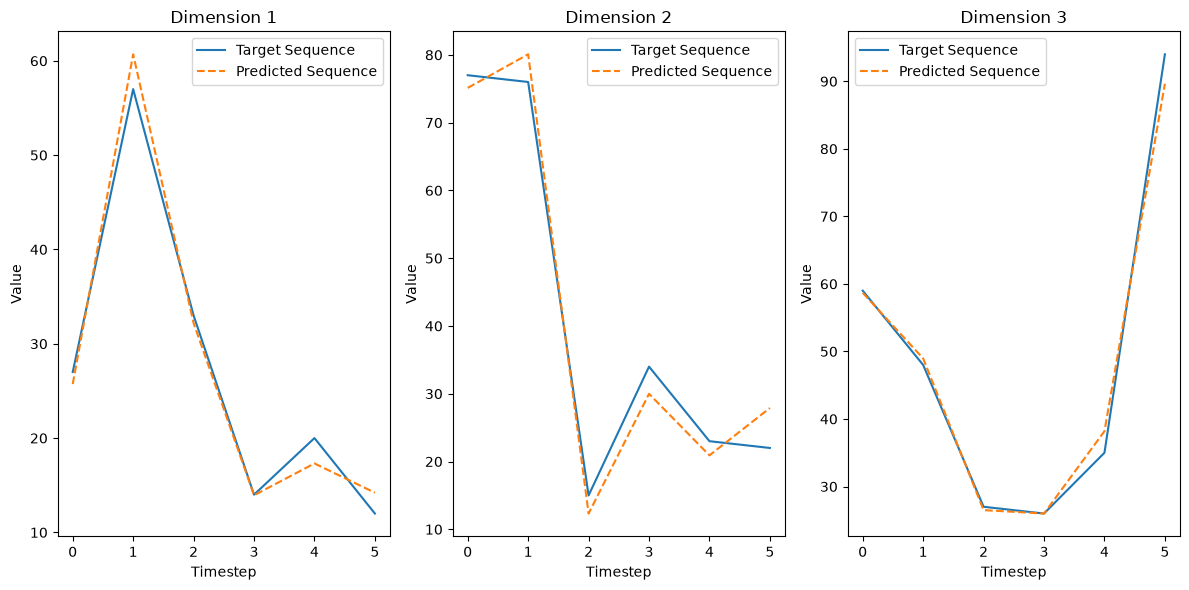

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 입력 시퀀스를 시간 축으로 뒤집고 1을 더함
reversed_input_sequence = np.flip(new_input_sequence, axis=1) + 1

# 입력 시퀀스와 예측 시퀀스를 시각화
def plot_sequences(modified_input_sequence, predicted_sequence):
    timesteps = modified_input_sequence.shape[1]
    input_dim = modified_input_sequence.shape[2]
    
    plt.figure(figsize=(12, 6))
    
    for dim in range(input_dim):
        plt.subplot(1, input_dim, dim + 1)
        plt.plot(range(timesteps), modified_input_sequence[0, :, dim], label='Target Sequence')
        plt.plot(range(timesteps), predicted_sequence[:, dim], label='Predicted Sequence', linestyle='--')
        plt.title(f'Dimension {dim + 1}')
        plt.xlabel('Timestep')
        plt.ylabel('Value')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# 시각화 함수 호출
plot_sequences(reversed_input_sequence, predicted_sequence)


## 보다 일반적인 attention mechanism

나중에 살펴볼 Transformer 등 일반적인 어텐션 모형에서는 쿼리, 키, 값의 세 가지 벡터들을 이용하여 attention 메커니즘을 정의한다.

여기에 훈련 가능한 가중치 행렬 $W$들을 이용하여 쿼리, 키, 값을 생성하는 방법을 살펴본다.

- 쿼리(Q)
  * 디코더의 출력 벡터에 학습 가능한 가중치 행렬 $W_q$를 곱하여 쿼리를 생성한다.  
  * 디코더는 현재 어떤 정보를 참조할지 결정하기 위해 자신의 상태(출력)를 기준으로 삼는다. <br><br>  
 
    
- 키(K)와 값(V):
  - 인코더의 출력에 각각 행렬 `W_k`와 `W_v`를 곱하여 키와 값을 생성한다.
  - Key는 입력 시퀀스의 각 위치가 담고 있는 정보의 "주소" 역할을 하며,
  - Value는 해당 위치의 실제 "내용"이다.
  - 인코더의 출력은 입력 시퀀스의 각 부분을 나타내며, 디코더가 이들 중 어떤 것이 필요한지를 판단할 수 있도록 한다.

**추가 확인:** 본격적으로 네트워크를 구성하기 전에, `numpy`를 이용한 시각화 예제를 살펴본다.
    
아래 예제에서는 가중치 행렬 `W`들을 간단히 정의하였지만, 실제 뉴럴 네트워크 모형에서는 훈련 가능한 파라미터들로 구성된다.

한편, 아래 코드에서 `W`들의 shape은 `(latent_dim, latent_dim)`로 하여, 생성된 쿼리/키, 값의 차원을 `latent_dim`로 동일하게 하였다.

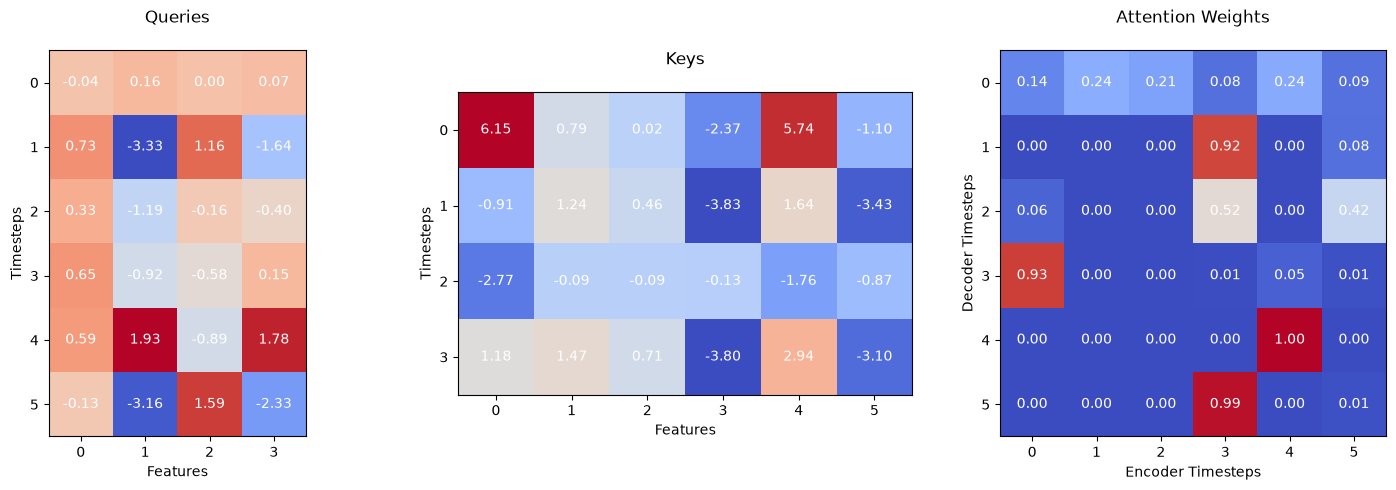

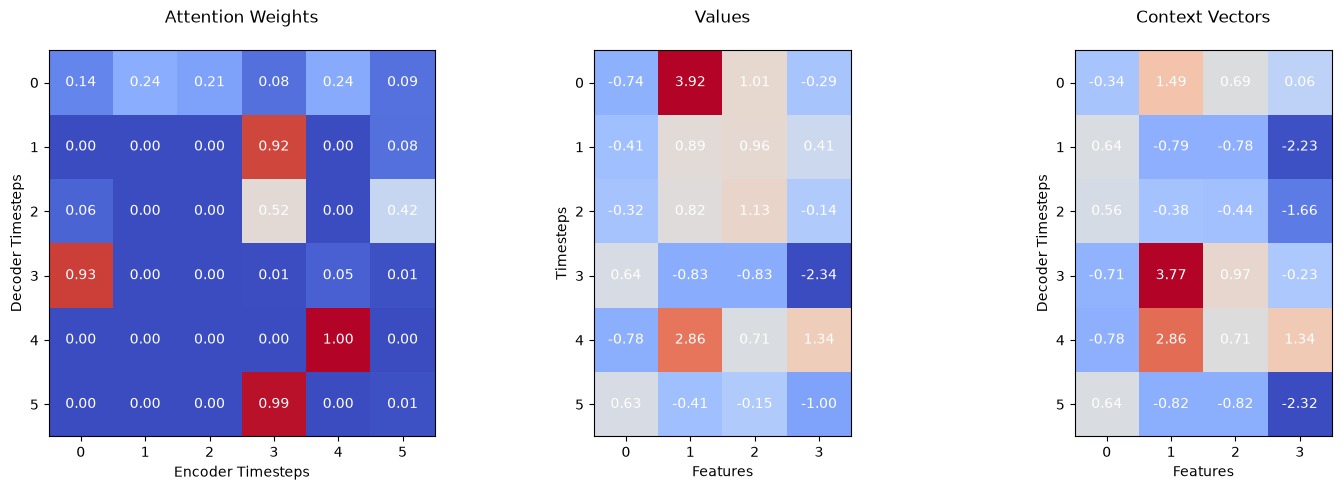

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 설정
encoder_timesteps = 6
decoder_timesteps = 6
latent_dim = 4

# 인코더 출력 (임의의 값)
encoder_outputs = np.random.normal(0, 1, size=(encoder_timesteps, latent_dim))

# 디코더 출력
decoder_outputs = np.roll(encoder_outputs, shift=1, axis=0)
decoder_outputs[0] = np.random.normal(0, 0.1, latent_dim)
decoder_outputs = decoder_outputs + np.random.normal(0, 0.01, decoder_outputs.shape)

# 가상의 가중치 행렬 생성 (랜덤하게 생성함)
W_q = np.random.normal(0, 1, (latent_dim, latent_dim))
W_k = np.random.normal(0, 1, (latent_dim, latent_dim))
W_v = np.random.normal(0, 1, (latent_dim, latent_dim))

# 쿼리, 키, 값 생성
queries = np.dot(decoder_outputs, W_q)
keys = np.dot(encoder_outputs, W_k)
values = np.dot(encoder_outputs, W_v)

# 어텐션 가중치 계산 (여기서는 단순한 내적)
attention_scores = np.dot(queries, keys.T)

# Softmax 적용하여 가중치 정규화
attention_weights = np.exp(attention_scores) / np.sum(np.exp(attention_scores), axis=1, keepdims=True)

# Context 벡터 계산
context_vectors = np.dot(attention_weights, values)


# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_matrix(axes[0], queries, 'Queries', 'Features', 'Timesteps')

plot_matrix(axes[1], keys.T, 'Keys', 'Features', 'Timesteps')

plot_matrix(axes[2], attention_weights, 'Attention Weights', 'Encoder Timesteps', 'Decoder Timesteps')

plt.tight_layout()
plt.show()

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_matrix(axes[0], attention_weights, 'Attention Weights', 'Encoder Timesteps', 'Decoder Timesteps')

plot_matrix(axes[1], values, 'Values', 'Features', 'Timesteps')

plot_matrix(axes[2], context_vectors, 'Context Vectors', 'Features', 'Decoder Timesteps')

plt.tight_layout()
plt.show()


### 일반적 상황에서의 쿼리/키, 값의 차원

`W`들의 열의 개수를 조정하여, 생성되는 쿼리/키, 값의 차원을 조절할 수 있다. 일반적인 상황에 대해서는 다음의 표를 참고하라.


| 항목                   | shape            | 설명                 |
| -------------------- | ---------------- | ------------------ |
| `W_q`                | `(d_model, d_k)` | 입력을 쿼리로 변환하는 가중치   |
| `W_k`                | `(d_model, d_k)` | 입력을 키로 변환하는 가중치    |
| `W_v`                | `(d_model, d_v)` | 입력을 값으로 변환하는 가중치   |
| `Q`                  | `(T_q, d_k)`     | 디코더 또는 입력에서 생성된 쿼리 |
| `K`                  | `(T_k, d_k)`      | 인코더 출력에서 생성된 키     |
| `V`                  | `(T_k, d_v)`      | 인코더 출력에서 생성된 값     |
| `Attention(Q, K, V)` | `(T_q, d_v)`     | 최종 컨텍스트 벡터         |

- `d_model` : 모형의 dimension, 위 예제에서는 `encoder_output` dimension인 `latent_dim`에 해당
- `T_q` : Query의 시퀀스 길이, `T_k` : Key와 Value의 시퀀스 길이 (고정 길이 예제에서는 우연히 $T_q=T_k=6$이지만, 일반적인 표기는 구분하는 것이 맞다)
- `d_k` : 쿼리와 키의 차원, `d_v` : value의 차원

### 뉴럴 네트워크를 통한 구성

뉴럴 네트워크를 이용하여 인코더 디코더 모델이 구현하여 보자.

쿼리, 키, 값을 생성하기 위한 가중치 행렬을 `Dense`로 생성하는 부분을 제외하고는 앞서 구현한 인코더-디코더 예제와 동일하다.

`W` 출력들의 dimension은 `latent_dim`로 하였으나, 이전에 설명한대로 조정 가능하다.

```
# 쿼리, 키, 값 가중치 생성
W_q = Dense(latent_dim, use_bias=False, name='W_q')
W_k = Dense(latent_dim, use_bias=False, name='W_k')
W_v = Dense(latent_dim, use_bias=False, name='W_v')

# 쿼리, 키, 값 계산
queries = W_q(decoder_outputs)
keys = W_k(encoder_outputs)
values = W_v(encoder_outputs)
```

In [29]:
from keras.layers import Input, LSTM, Dense, Concatenate, Dot, Activation
from keras.models import Model

# 입력 데이터 및 모델 파라미터 설정
timesteps = 6
input_dim = 3
latent_dim = 50

In [30]:
# 인코더 정의
encoder_inputs = Input(shape=(timesteps, input_dim), name='encoder_input')
encoder_lstm = LSTM(latent_dim, return_state=True, return_sequences=True, name='encoder_lstm')
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# 디코더 정의
decoder_inputs = Input(shape=(timesteps, input_dim), name='decoder_input')
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)

# 쿼리, 키, 값 가중치 생성
W_q = Dense(latent_dim, use_bias=False, name='W_q')
W_k = Dense(latent_dim, use_bias=False, name='W_k')
W_v = Dense(latent_dim, use_bias=False, name='W_v')

# 쿼리, 키, 값 계산
queries = W_q(decoder_outputs)
keys = W_k(encoder_outputs)
values = W_v(encoder_outputs)

# 어텐션 스코어 계산
attention_scores = Dot(axes=[2, 2])([queries, keys])

# Softmax 적용
attention_weights = Activation('softmax')(attention_scores)

# 컨텍스트 벡터 계산
context_vectors = Dot(axes=[2, 1])([attention_weights, values])

# 컨텍스트 벡터와 디코더 출력 결합
decoder_combined_context = Concatenate(axis=-1)([context_vectors, decoder_outputs])

# 출력층 정의
decoder_dense = Dense(input_dim, activation='linear', name='decoder_output')
decoder_outputs = decoder_dense(decoder_combined_context)

# 모델 정의
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# 모델 요약 출력
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 6, 50),   │     10,800 │ encoder_input[0]… │
│                     │ (None, 50),       │            │                   │
│                     │ (None, 50)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 6, 50),   │     10,800 │ decoder_input[0]… │
│                     │ (None, 50),       │            │ encoder_lstm[0][… │
│                     │ (None, 50)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_q (Dense)         │ (None, 6, 50)     │      2,500 │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_k (Dense)         │ (None, 6, 50)     │      2,500 │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_2 (Dot)         │ (None, 6, 6)      │          0 │ W_q[0][0],        │
│                     │                   │            │ W_k[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 6, 6)      │          0 │ dot_2[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_v (Dense)         │ (None, 6, 50)     │      2,500 │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_3 (Dot)         │ (None, 6, 50)     │          0 │ activation[0][0], │
│                     │                   │            │ W_v[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 6, 100)    │          0 │ dot_3[0][0],      │
│ (Concatenate)       │                   │            │ decoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 6, 3)      │        303 │ concatenate_1[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,403 (114.86 KB)

 Trainable params: 29,403 (114.86 KB)

 Non-trainable params: 0 (0.00 B)

모델에서 데이터의 흐름은 다음과 같다.

```
encoder_input → [Encoder LSTM] → encoder_outputs, state_h, state_c
                                      ↓  
decoder_input → [Decoder LSTM] (uses state_h, state_c) → decoder_outputs
                                      ↓  
                decoder_outputs → [Dense (W_q)] → queries
                encoder_outputs → [Dense (W_k)] → keys
                encoder_outputs → [Dense (W_v)] → values
                                      ↓  
          [Dot Product] (queries, keys) → attention_scores
                                      ↓  
                  [Softmax] → attention_weights
                                      ↓  
       [Dot Product] (attention_weights, values) → context_vectors
                                      ↓  
         [Concatenate] ([context_vectors, decoder_outputs])  → [Dense] → final_output
```

여기서는 Attention의 원리를 간단히 보기 위해 scaling을 생략하였다. Transformer에서는 score가 지나치게 커지는 것을 완화하기 위해 $QK^\top$을 $\sqrt{d_k}$로 나눈다.

$$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

In [31]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [32]:
history = model.fit([input_sequences, decoder_input_data], target_data, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

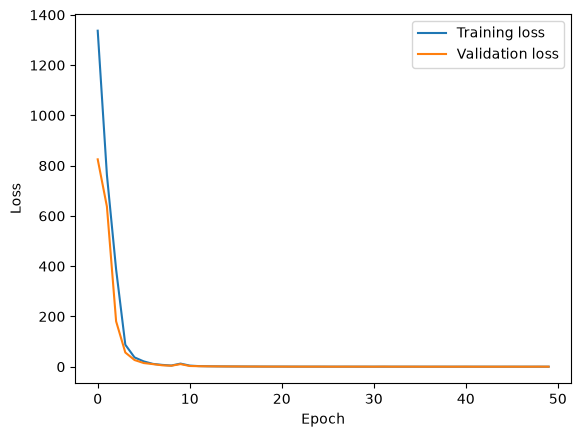

In [33]:
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 예측 (심화 구현)

예측 파트 또한 이전에 구현한 인코더-디코더 모형과 거의 동일하다.

In [34]:
# 예측을 위한 모델 설정
encoder_model = Model(encoder_inputs, [encoder_outputs, state_h, state_c])
encoder_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 6, 3)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ [(None, 6, 50), (None, │        10,800 │
│                                 │ 50), (None, 50)]       │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,800 (42.19 KB)

 Trainable params: 10,800 (42.19 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# 디코더의 입력이 한 번에 하나의 값을 받음
decoder_single_input = Input(shape=(1, input_dim), name="previous_prediction")
decoder_state_input_h = Input(shape=(latent_dim,), name="hidden_status")
decoder_state_input_c = Input(shape=(latent_dim,), name="cell_status")
encoder_output_input = Input(shape=(timesteps, latent_dim), name="encoder_output")

decoder_outputs, state_h, state_c = decoder_lstm(decoder_single_input, initial_state=[decoder_state_input_h, decoder_state_input_c])

# 쿼리, 키, 값 계산
queries = W_q(decoder_outputs)
keys = W_k(encoder_output_input)
values = W_v(encoder_output_input)

# 컨텍스트 벡터 계산
attention_scores = Dot(axes=[2, 2])([queries, keys])
attention_weights = Activation('softmax')(attention_scores)
context_vectors = Dot(axes=[2, 1])([attention_weights, values])

# 컨텍스트 벡터와 디코더 출력 결합
decoder_combined_context = Concatenate(axis=-1)([context_vectors, decoder_outputs])

# 출력층 정의
decoder_outputs = decoder_dense(decoder_combined_context)

decoder_states = [state_h, state_c]

decoder_model = Model(
    inputs=[decoder_single_input, encoder_output_input, decoder_state_input_h, decoder_state_input_c],
    outputs=[decoder_outputs] + decoder_states)

decoder_model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ previous_prediction │ (None, 1, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_status       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cell_status         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 50),   │     10,800 │ previous_predict… │
│                     │ (None, 50),       │            │ hidden_status[0]… │
│                     │ (None, 50)]       │            │ cell_status[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_output      │ (None, 6, 50)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_q (Dense)         │ (None, 1, 50)     │      2,500 │ decoder_lstm[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_k (Dense)         │ (None, 6, 50)     │      2,500 │ encoder_output[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_4 (Dot)         │ (None, 1, 6)      │          0 │ W_q[1][0],        │
│                     │                   │            │ W_k[1][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 6)      │          0 │ dot_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_v (Dense)         │ (None, 6, 50)     │      2,500 │ encoder_output[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_5 (Dot)         │ (None, 1, 50)     │          0 │ activation_1[0][… │
│                     │                   │            │ W_v[1][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 1, 100)    │          0 │ dot_5[0][0],      │
│ (Concatenate)       │                   │            │ decoder_lstm[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 1, 3)      │        303 │ concatenate_2[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,603 (72.67 KB)

 Trainable params: 18,603 (72.67 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:

# 새로운 입력 시퀀스
new_input_sequence = np.array([[[11., 21., 93.],
                                [19., 22., 34.],
                                [13., 33., 25.],
                                [32., 14., 26.],
                                [56., 75., 47.],
                                [26., 76., 58.]]])

encoder_output, h, c = encoder_model.predict(new_input_sequence, verbose=0)

# 디코더의 초기 입력 (시작 토큰)
target_seq = np.zeros((1, 1, input_dim))
target_seq[0, 0, :] = 0.0

predicted_sequence = []

for t in range(timesteps):
    output_tokens, h, c = decoder_model.predict([target_seq, encoder_output, h, c], verbose=0)

    print("Predicted value in this step: ", output_tokens[0, 0, :], "based on", target_seq[0,0,:])
    # 가장 최근의 디코더 출력을 저장
    predicted_sequence.append(output_tokens[0, 0, :])

    # 다음 타임스텝을 위한 디코더 입력 준비 (현재 출력 사용)
    target_seq = np.zeros((1, 1, input_dim))
    target_seq[0, 0, :] = output_tokens[0, 0, :]

predicted_sequence = np.array(predicted_sequence)

print("New_input_sequence:")
print(new_input_sequence)

print("Predicted sequence:")
print(predicted_sequence)

Predicted value in this step:  [27.205318 76.725876 58.37229 ] based on [0. 0. 0.]
Predicted value in this step:  [57.190872 75.48734  47.37337 ] based on [27.20531845 76.72587585 58.37229156]


Predicted value in this step:  [32.86758  14.605335 26.629725] based on [57.19087219 75.48734283 47.37337112]
Predicted value in this step:  [13.975779 33.628986 25.641645] based on [32.86758041 14.60533524 26.6297245 ]


Predicted value in this step:  [20.315279 22.957258 34.672813] based on [13.97577858 33.62898636 25.64164543]
Predicted value in this step:  [12.052386 21.920599 93.816216] based on [20.31527901 22.95725822 34.67281342]
New_input_sequence:
[[[11. 21. 93.]
  [19. 22. 34.]
  [13. 33. 25.]
  [32. 14. 26.]
  [56. 75. 47.]
  [26. 76. 58.]]]
Predicted sequence:
[[27.205318 76.725876 58.37229 ]
 [57.190872 75.48734  47.37337 ]
 [32.86758  14.605335 26.629725]
 [13.975779 33.628986 25.641645]
 [20.315279 22.957258 34.672813]
 [12.052386 21.920599 93.816216]]


이 예측 과정의 데이터 흐름은 다음과  같다.
```
test_input → [Trained Encoder LSTM] → state_h, state_c, encoder_outputs
                                        ↓  
start_token                             ↓
 → [Trained Decoder LSTM] (state_h, state_c) → state_h, state_c, decoder_outputs
 → [Denses (W_q, W_k, W_v)] (encoder_outputs, decoder_outputs) → queries, keys, values                                      
 → [Attention] (queries, keys, values) → context → [Concatenate] ([context, decoder_outputs]) → [Trained Dense] 
    → next_value                        ↓
       → [Trained Decoder LSTM] (state_h, state_c) → state_h, state_c, decoder_outputs
       → [Denses (W_q, W_k, W_v)] (encoder_outputs, decoder_outputs) → queries, keys, values                                        
       → [Attention] (decoder_outputs, encoder_ouputs) → context → [Concatenate] ([context, decoder_outputs]) → [Trained Dense]
          → next_value 
                                  (Repeat)
```

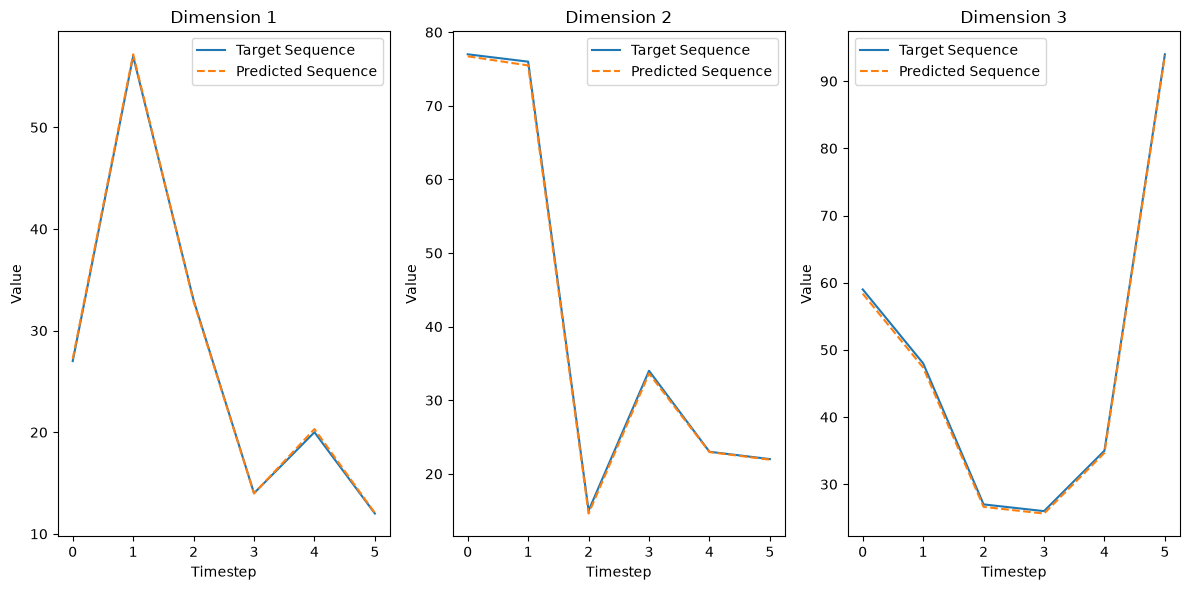

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 입력 시퀀스를 시간 축으로 뒤집고 1을 더함
reversed_input_sequence = np.flip(new_input_sequence, axis=1) + 1

# 입력 시퀀스와 예측 시퀀스를 시각화
def plot_sequences(modified_input_sequence, predicted_sequence):
    timesteps = modified_input_sequence.shape[1]
    input_dim = modified_input_sequence.shape[2]
    
    plt.figure(figsize=(12, 6))
    
    for dim in range(input_dim):
        plt.subplot(1, input_dim, dim + 1)
        plt.plot(range(timesteps), modified_input_sequence[0, :, dim], label='Target Sequence')
        plt.plot(range(timesteps), predicted_sequence[:, dim], label='Predicted Sequence', linestyle='--')
        plt.title(f'Dimension {dim + 1}')
        plt.xlabel('Timestep')
        plt.ylabel('Value')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# 시각화 함수 호출
plot_sequences(reversed_input_sequence, predicted_sequence)
